In [ ]:
import pandas as pd
import altair as alt

In [ ]:
#kaggle data
import kagglehub


path = kagglehub.dataset_download("spingere/usa-macroeconomic-rate-of-changes-1993-2025")

print("Path to dataset files:", path)

100%|██████████| 13.2k/13.2k [00:00<00:00, 3.54MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/spingere/usa-macroeconomic-rate-of-changes-1993-2025/versions/2


In [ ]:


url = 'https://raw.githubusercontent.com/Taylorbeuke/Project3/main/GINI_COEF%20(1).csv'
gini_df = pd.read_csv(url, skiprows=3)

gini_df.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,Unnamed: 68
0,Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:


#skip first 3
url = 'https://raw.githubusercontent.com/Taylorbeuke/Project3/main/GINI_COEF%20(1).csv'
gini_df = pd.read_csv(url, skiprows=3)

#US only filter
us_gini = gini_df[gini_df['Country Name'] == 'United States']


us_gini_melted = us_gini.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Gini'
)


us_gini_melted = us_gini_melted.dropna(subset=['Gini'])
us_gini_melted['Year'] = us_gini_melted['Year'].astype(int)
us_gini_melted['Gini'] = us_gini_melted['Gini'].astype(float)


chart = alt.Chart(us_gini_melted).mark_line(point=True).encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y('Gini:Q', title='Gini Coefficient', scale=alt.Scale(domain=[30, 45])),
    tooltip=['Year', 'Gini']
).properties(
    title='Gini Coefficient Over Time (United States)',
    width=600,
    height=400
)

chart


alt.Chart(...)

In [ ]:
us_gini_melted.to_csv("us_gini_coef.csv", index=False)

# Download the file to your local machine
from google.colab import files
files.download("us_gini_coef.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

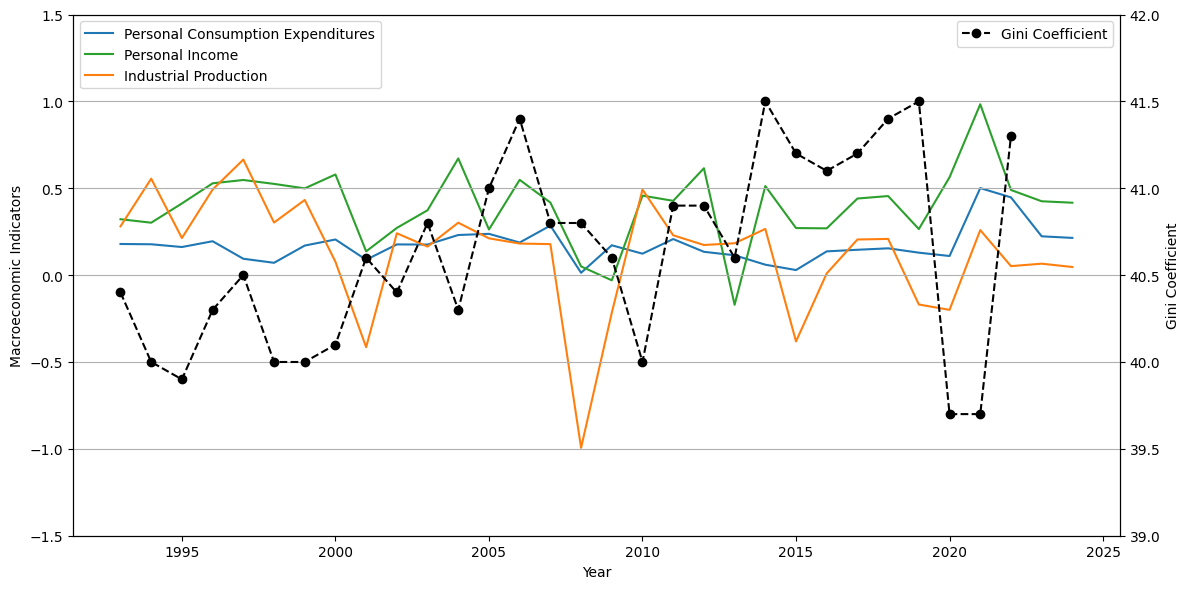

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

#gini data
gini_url = 'https://raw.githubusercontent.com/Taylorbeuke/Project3/main/GINI_COEF%20(1).csv'
gini_df = pd.read_csv(gini_url, skiprows=3)
us_gini = gini_df[gini_df['Country Name'] == 'United States']
us_gini_melted = us_gini.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Gini'
)
us_gini_melted = us_gini_melted.dropna(subset=['Gini'])
us_gini_melted['Year'] = us_gini_melted['Year'].astype(int)
us_gini_melted = us_gini_melted[us_gini_melted['Year'] >= 1993]

#macro data
file_path = os.path.join(path, "macro_monthly.csv")
macro_df = pd.read_csv(file_path)

macro_yearly = macro_df.groupby('Year')[[
    'Personal_Consumption_Expenditures',
    'Personal_Income',
    'Industrial_Production'
]].mean().reset_index()
macro_yearly = macro_yearly[macro_yearly['Year'] >= 1993]


fig, ax1 = plt.subplots(figsize=(12, 6))

# macro axis
ax1.plot(macro_yearly['Year'], macro_yearly['Personal_Consumption_Expenditures'], label='Personal Consumption Expenditures', color='tab:blue')
ax1.plot(macro_yearly['Year'], macro_yearly['Personal_Income'], label='Personal Income', color='tab:green')
ax1.plot(macro_yearly['Year'], macro_yearly['Industrial_Production'], label='Industrial Production', color='tab:orange')
ax1.set_xlabel('Year')
ax1.set_ylabel('Macroeconomic Indicators')
ax1.tick_params(axis='y')
ax1.legend(loc='upper left')
ax1.set_ylim([-1.5, 1.5])

# gini axis
ax2 = ax1.twinx()
ax2.plot(us_gini_melted['Year'], us_gini_melted['Gini'], label='Gini Coefficient', color='black', linestyle='--', marker='o')
ax2.set_ylabel('Gini Coefficient')
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend(loc='upper right')
ax2.set_ylim([39.0, 42.0])


plt.grid(True)
plt.tight_layout()
plt.show()


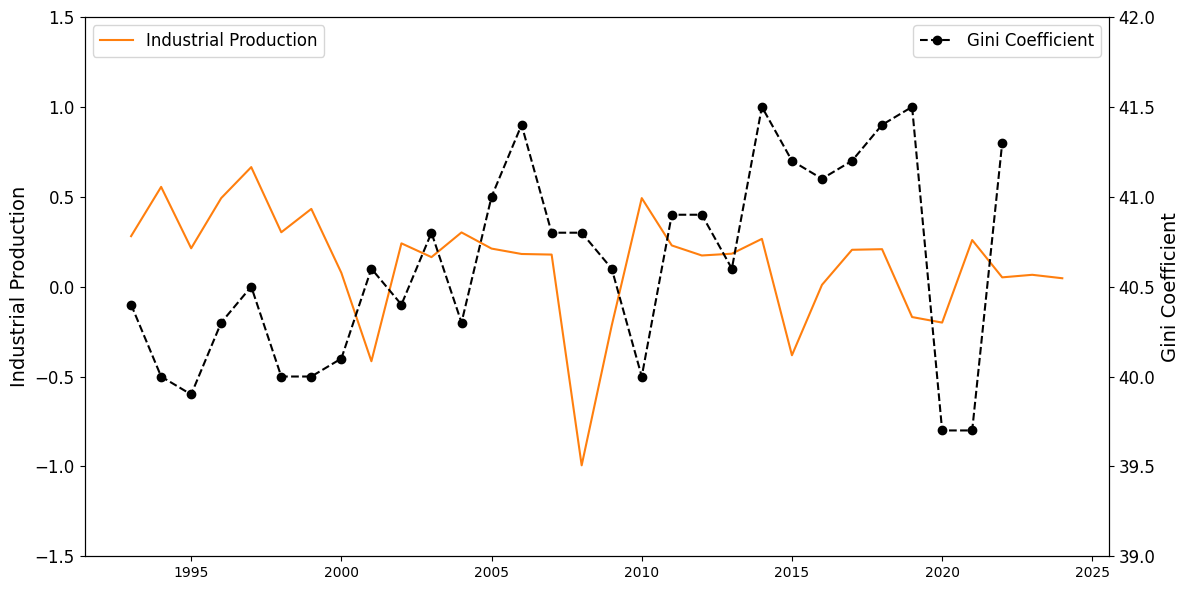

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os

gini_url = 'https://raw.githubusercontent.com/Taylorbeuke/Project3/main/GINI_COEF%20(1).csv'
gini_df = pd.read_csv(gini_url, skiprows=3)
us_gini = gini_df[gini_df['Country Name'] == 'United States']
us_gini_melted = us_gini.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Gini'
)
us_gini_melted = us_gini_melted.dropna(subset=['Gini'])
us_gini_melted['Year'] = us_gini_melted['Year'].astype(int)
us_gini_melted = us_gini_melted[us_gini_melted['Year'] >= 1993]


file_path = os.path.join(path, "macro_monthly.csv")
macro_df = pd.read_csv(file_path)

macro_yearly = macro_df.groupby('Year')[['Industrial_Production']].mean().reset_index()
macro_yearly = macro_yearly[macro_yearly['Year'] >= 1993]


fig, ax1 = plt.subplots(figsize=(12, 6))

#industrial production
ax1.plot(macro_yearly['Year'], macro_yearly['Industrial_Production'],
         label='Industrial Production', color='tab:orange')
ax1.set_ylabel('Industrial Production', fontsize=14)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_ylim([-1.5, 1.5])
ax1.legend(loc='upper left', fontsize=12)

#gini coefficient
ax2 = ax1.twinx()
ax2.plot(us_gini_melted['Year'], us_gini_melted['Gini'],
         label='Gini Coefficient', color='black', linestyle='--', marker='o')
ax2.set_ylabel('Gini Coefficient', fontsize=14)
ax2.tick_params(axis='y', labelcolor='black', labelsize=12)
ax2.set_ylim([39.0, 42.0])
ax2.legend(loc='upper right', fontsize=12)


plt.grid(False)
plt.tight_layout()
plt.show()


In [ ]:
import altair as alt
import pandas as pd
import os

# Load Gini
gini_url = 'https://raw.githubusercontent.com/Taylorbeuke/Project3/main/GINI_COEF%20(1).csv'
gini_df = pd.read_csv(gini_url, skiprows=3)
us_gini = gini_df[gini_df['Country Name'] == 'United States']
us_gini_melted = us_gini.melt(
    id_vars=['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code'],
    var_name='Year',
    value_name='Gini'
)
us_gini_melted = us_gini_melted.dropna(subset=['Gini'])
us_gini_melted['Year'] = us_gini_melted['Year'].astype(int)
us_gini_melted = us_gini_melted[us_gini_melted['Year'] >= 1993]

# Load macro data
file_path = os.path.join(path, "macro_monthly.csv")
macro_df = pd.read_csv(file_path)
macro_yearly = macro_df.groupby('Year')[['Industrial_Production']].mean().reset_index()
macro_yearly = macro_yearly[macro_yearly['Year'] >= 1993]

# Merge for single dataframe
combined = pd.merge(macro_yearly, us_gini_melted[['Year', 'Gini']], on='Year')

# Create base chart
base = alt.Chart(combined).encode(x=alt.X('Year:O', axis=alt.Axis(title='Year')))

# Line for Industrial Production
industrial_line = base.mark_line(color='orange').encode(
    y=alt.Y('Industrial_Production:Q', axis=alt.Axis(title='Industrial Production'),
            scale=alt.Scale(domain=[-1.5, 1.5])),
    tooltip=['Year', 'Industrial_Production']
)

# Line for Gini
gini_line = base.mark_line(color='black', strokeDash=[5, 5]).encode(
    y=alt.Y('Gini:Q', axis=alt.Axis(title='Gini Coefficient'),
            scale=alt.Scale(domain=[39.0, 42.0])),
    tooltip=['Year', 'Gini']
)

# Combine in layered chart with dual axes
chart = alt.layer(
    industrial_line,
    gini_line
).resolve_scale(
    y='independent'
).properties(
    width=700,
    height=400,
    title="U.S. Industrial Production vs. Gini Coefficient (1993+)"
).configure_axis(
    grid=False
).interactive()

chart

alt.LayerChart(...)

In [ ]:
import pandas as pd
import altair as alt

# --- Reshape data ---
long_df = combined.melt(id_vars='Year', var_name='Metric', value_name='Value')

# Set Y-axis domains for both metrics
y_domains = {
    'Industrial_Production': [-1.5, 1.5],
    'Gini': [39.0, 42.0]
}

# Define hover selection on year
hover = alt.selection_point(
    fields=["Year"],
    nearest=True,
    on="pointermove",
    clear="mouseout"
)

# Base chart
base = alt.Chart(long_df).encode(
    x=alt.X('Year:O', axis=alt.Axis(title='Year', grid=False))
)

# Lines for both metrics
lines = base.mark_line().encode(
    y=alt.Y('Value:Q',
            axis=alt.Axis(title=None, grid=False),
            scale=alt.Scale(zero=False)),
    color=alt.Color('Metric:N',
                    legend=alt.Legend(title='Metric')),
)

# Points that appear on hover
points = base.mark_circle(size=65).encode(
    y='Value:Q',
    color='Metric:N',
    opacity=alt.condition(hover, alt.value(1), alt.value(0))
)

# Tooltip text
text = base.mark_text(align='left', dx=5, dy=-5).encode(
    y='Value:Q',
    color='Metric:N',
    text=alt.condition(hover, 'Value:Q', alt.value('')),
    opacity=alt.condition(hover, alt.value(1), alt.value(0))
)

# Vertical rule at hovered year
rule = base.mark_rule(color='gray').encode(
    x='Year:O'
).transform_filter(hover)

# Selector to activate hover
selectors = base.mark_point(opacity=0).add_params(hover)

# Final chart
chart = alt.layer(
    lines,
    selectors,
    points,
    text,
    rule
).facet(
    row=alt.Row('Metric:N', sort=['Industrial_Production', 'Gini'], title=None)
).resolve_scale(
    y='independent'
).properties(
    width=700,
    height=200,
    title="U.S. Industrial Production vs. Gini Coefficient (1993+)"
).configure_axis(
    grid=False
)

chart




SchemaValidationError: `FacetChart` has no parameter named 'height'

Existing parameter names are:
data    autosize     columns       name      spacing     
facet   background   config        padding   title       
spec    bounds       datasets      params    transform   
align   center       description   resolve   usermeta    

See the help for `FacetChart` to read the full description of these parameters

alt.FacetChart(...)

In [ ]:
import kagglehub
import os


# Download latest version
path = kagglehub.dataset_download("spingere/usa-macroeconomic-rate-of-changes-1993-2025")

print("Path to dataset files:", path)



#Personal_Consumption_Expenditures
#Personal_Income
#Industrial_Production


Path to dataset files: /kaggle/input/usa-macroeconomic-rate-of-changes-1993-2025


In [ ]:
file_path = os.path.join(path, "macro_monthly.csv")
df = pd.read_csv(file_path)
df.head()

,Year,Month,Industrial_Production,Manufacturers_New_Orders: Durable Goods,Consumer_Price Index,Unemployment_Rate,Retail_Sales,Producer_Price_Index,Personal_Consumption_Expenditures,National_Home_Price_Index,All_Employees(Total_Nonfarm),Labor_Force_Participation_Rate,Federal_Funds_Effective_Rate,Building_Permits,Money_Supply_(M2),Personal_Income,Trade_Balance,Consumer_Sentiment,Consumer_Confidence
0,1993,1,0.39,-3.52,0.35,-1.35,1.16,0.34,0.24,0.14,0.26,-0.15,-0.51,0.09,-0.16,-2.51,30.91,-1.87,-1.87
1,1993,2,0.48,5.93,0.21,-2.74,-0.78,0.34,0.15,0.07,0.23,0.00,0.59,-2.46,-0.13,0.61,7.10,-3.02,-3.02
2,1993,3,-0.10,-1.62,0.14,-1.41,-0.83,0.25,0.20,0.04,-0.04,0.00,0.40,-8.01,-0.08,-0.05,-88.46,-0.81,-0.81
3,1993,4,0.28,0.50,0.35,1.43,2.58,0.51,0.27,0.09,0.27,-0.15,-0.34,4.55,-0.01,1.02,4.90,-0.35,-0.35
4,1993,5,-0.37,-0.68,0.28,0.00,0.95,0.34,0.31,0.13,0.25,0.45,-0.30,0.72,0.75,0.29,32.21,-6.19,-6.19


In [ ]:



# Group by Year and take the average of the selected indicators
yearly_df = df.groupby('Year')[[
    'Personal_Consumption_Expenditures',
    'Personal_Income',
    'Industrial_Production'
]].mean().reset_index()

# Melt the DataFrame to long format for Altair
melted = yearly_df.melt(id_vars='Year',
                        var_name='Indicator',
                        value_name='Value')

# Create line chart
chart = alt.Chart(melted).mark_line(point=True).encode(
    x=alt.X('Year:O', title='Year'),
    y=alt.Y('Value:Q', title='Value'),
    color='Indicator:N',
    tooltip=['Year', 'Indicator', 'Value']
).properties(
    title='U.S. Macroeconomic Indicators Over Time',
    width=700,
    height=400
)

chart


alt.Chart(...)

In [ ]:
data= pd.read_csv("https://drive.google.com/uc?id=1xvGFdWBW_ZRIjvbaeEfZh7-8fbzff9sI")
data


,Country name,year,Life Ladder,Log GDP per capita,Social support,Healthy life expectancy at birth,Freedom to make life choices,Generosity,Perceptions of corruption,Positive affect,Negative affect
0,Afghanistan,2008,3.724,7.370,0.451,50.80,0.718,0.168,0.882,0.518,0.258
1,Afghanistan,2009,4.402,7.540,0.552,51.20,0.679,0.190,0.850,0.584,0.237
2,Afghanistan,2010,4.758,7.647,0.539,51.60,0.600,0.121,0.707,0.618,0.275
3,Afghanistan,2011,3.832,7.620,0.521,51.92,0.496,0.162,0.731,0.611,0.267
4,Afghanistan,2012,3.783,7.705,0.521,52.24,0.531,0.236,0.776,0.710,0.268
...,...,...,...,...,...,...,...,...,...,...,...
1944,Zimbabwe,2016,3.735,7.984,0.768,54.40,0.733,-0.095,0.724,0.738,0.209
1945,Zimbabwe,2017,3.638,8.016,0.754,55.00,0.753,-0.098,0.751,0.806,0.224
1946,Zimbabwe,2018,3.616,8.049,0.775,55.60,0.763,-0.068,0.844,0.710,0.212
1947,Zimbabwe,2019,2.694,7.950,0.759,56.20,0.632,-0.064,0.831,0.716,0.235


In [ ]:
#macrodata
import requests

url = 'https://raw.githubusercontent.com/Taylorbeuke/Project3/main/usa-macroeconomic-rate-of-changes-1993-2025-metadata.json'
response = requests.get(url)
metadata = response.json()

# Print top-level keys to see the structure
print(metadata.keys())




dict_keys(['@context', 'alternateName', 'conformsTo', 'license', 'distribution', 'recordSet', 'version', 'keywords', 'isAccessibleForFree', 'includedInDataCatalog', 'creator', 'publisher', 'thumbnailUrl', 'dateModified', 'datePublished', '@type', 'name', 'url', 'description'])


Income Share


In [ ]:
!pip install pandas altair openpyxl
url = 'https://raw.githubusercontent.com/Taylorbeuke/Project3/main/tableA4a.xlsx'
incomeshare = pd.read_excel(url, engine='openpyxl')


HTTPError: HTTP Error 404: Not Found

In [ ]:
xls = pd.ExcelFile('https://raw.githubusercontent.com/Taylorbeuke/Project3/main/tableA4a.xlsx', engine='openpyxl')
incomeshare = pd.read_excel(xls, sheet_name='tableA4a', header=4)
income = incomeshare[:-25]
income.head()

HTTPError: HTTP Error 404: Not Found

In [ ]:
income.columns = ['Year'
,'10th Percentile'
,'20th Percentile'
,'30th Percentile'
,'40th Percentile'
,'50th Percentile'
,'60th Percentile'
,'70th Percentile'
,'80th Percentile'
,'90th Percentile'
,'95th Percentile'
,'Household Ratio 90/10'
, 'Household Ratio 90/50'
, 'Household Ratio 50/10']

cleaned_income = income.iloc[1:].reset_index(drop=True)
cleaned_income


NameError: name 'income' is not defined

In [ ]:
cleaned_income['Year'] = cleaned_income['Year'].astype(str).str.extract(r'(\d{4})').astype(int)
cleaned_income

,Year,10th Percentile,20th Percentile,30th Percentile,40th Percentile,50th Percentile,60th Percentile,70th Percentile,80th Percentile,90th Percentile,95th Percentile,Household Ratio 90/10,Household Ratio 90/50,Household Ratio 50/10
0,2023,18980,33000,47910,62200,80610,101000,127300,165300,234900,316100,12.38,2.91,4.25
1,2022,17780,31190,45680,60330,77540,97730,123400,159100,224500,306700,12.63,2.9,4.36
2,2021,17540,31360,45380,61590,79260,100500,126800,167000,237400,320600,13.53,2.99,4.52
3,2020,18310,31900,46680,61520,79560,100100,126900,166100,236300,321700,12.9,2.97,4.34
4,2019,18940,33200,47760,63240,81210,102200,129700,168400,237800,319200,12.55,2.93,4.29
5,2018,17550,30710,44390,59980,75790,95420,120200,155900,221100,298400,12.6,2.92,4.32
6,2017,17500,30380,42910,57780,74810,94420,119900,154900,222400,298700,12.71,2.97,4.27
7,2017,17400,30150,42850,57650,75100,94900,119700,155200,219100,290100,12.59,2.92,4.32
8,2016,16950,29890,43230,56780,73520,93230,117200,150700,212400,280500,12.53,2.89,4.34
9,2015,16660,28640,40520,54660,71000,90450,113900,147000,203700,269400,12.23,2.87,4.26


In [ ]:
from google.colab import files
cleaned_income.to_csv('cleaned_income.csv', index=False)
files.download('cleaned_income.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
cleaned_income.to_excel('cleaned_income2.xlsx', index = False)
files.download('cleaned_income2.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import altair as alt

# Ensure Year is integer
cleaned_income['Year'] = cleaned_income['Year'].astype(str).str.extract(r'(\d{4})').astype(int)

# Choose a specific year to visualize
selected_year = 2021

# Filter for that year
year_data = cleaned_income[cleaned_income['Year'] == selected_year]

# Melt the percentiles into long format
melted = year_data.melt(
    id_vars=['Year'],
    value_vars=['10th Percentile', '20th Percentile', '30th Percentile',
                '40th Percentile', '50th Percentile', '60th Percentile',
                '70th Percentile', '80th Percentile', '90th Percentile',
                '95th Percentile'],
    var_name='Income Group',
    value_name='Income'
)

melted['Income'] = melted['Income'].astype(float)

# Calculate angle (Altair uses radians)
melted['angle'] = melted['Income'] / melted['Income'].sum() * 2 * 3.1416

# Cumulative angles for arc positions
melted['cumulative'] = melted['angle'].cumsum()
melted['startAngle'] = melted['cumulative'] - melted['angle']
melted['endAngle'] = melted['cumulative']

# Create the pie chart
chart = alt.Chart(melted).mark_arc(innerRadius=50).encode(
    theta=alt.Theta(field="angle", type="quantitative"),
    color=alt.Color(field="Income Group", type="nominal"),
    tooltip=["Income Group", "Income"]
).properties(
    width=400,
    height=400,
    title=f"Income Percentile Distribution ({selected_year})"
)

chart


NameError: name 'cleaned_income' is not defined